# Instagram User Analytics

    1.Customer Segmentation Visualization
    Description: This visualization uses Principal Component Analysis (PCA) to reduce the dimensionality of customer data and then plots the resulting components. Different clusters are highlighted, showing how customers group together based on their features.

    Use Case:

    Targeted Marketing: Businesses can identify different customer segments to tailor marketing strategies and campaigns specifically for each group.
    Personalization: Helps in creating personalized offers or recommendations based on customer segments.

2. Customer Lifetime Value (CLV) Prediction
Description: This plot shows the distribution of the predicted Customer Lifetime Value (CLV), which represents the total revenue a business expects from a customer over their entire relationship.

    Use Case:

    Revenue Forecasting: Helps businesses understand the potential value of their customer base and forecast future revenues.
    Resource Allocation: Assists in determining where to invest marketing resources and which customer segments are most valuable.

3. Sales Forecasting
Description: This visualization plots historical sales data alongside future sales predictions. It helps in visualizing sales trends and forecasting future performance.

    Use Case:

    Demand Planning: Assists businesses in planning inventory and production based on predicted sales trends.
    Strategic Planning: Helps in setting sales targets and budgeting for future periods.

4. Feature Importance Visualization
    Description: This bar plot shows the importance of each feature used in the machine learning model. Higher bars indicate features that have a more significant impact on the model's predictions.

    Use Case:

    Feature Selection: Helps in understanding which features are most influential and could be prioritized or refined.
    Model Interpretation: Provides insights into what factors contribute most to predictions, aiding in decision-making.

5. Churn Prediction
    Description: The ROC curve (Receiver Operating Characteristic curve) evaluates the performance of a churn prediction model by plotting the True Positive Rate against the False Positive Rate.

    Use Case:

    Customer Retention: Helps in assessing the effectiveness of strategies designed to retain customers who are likely to churn.
    Model Evaluation: Provides a measure of model performance and helps in comparing different models or approaches.

Summary:

    This unified script combines various visualizations and machine learning models to provide a comprehensive view of customer data. It can be used to:

        Understand Customer Segments: Identify distinct groups within the customer base.
        Predict and Analyze CLV: Assess the potential revenue from customers and plan accordingly.
        Forecast Sales: Prepare for future sales trends and manage resources effectively.
        Evaluate Feature Importance: Optimize the features used in predictive models for better accuracy.
        Assess Model Performance: Use ROC curves to measure the effectiveness of churn prediction models and improve customer retention strategies.
These visualizations and analyses help businesses make data-driven decisions, optimize marketing and sales strategies, and ultimately enhance overall performance and profitability.

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


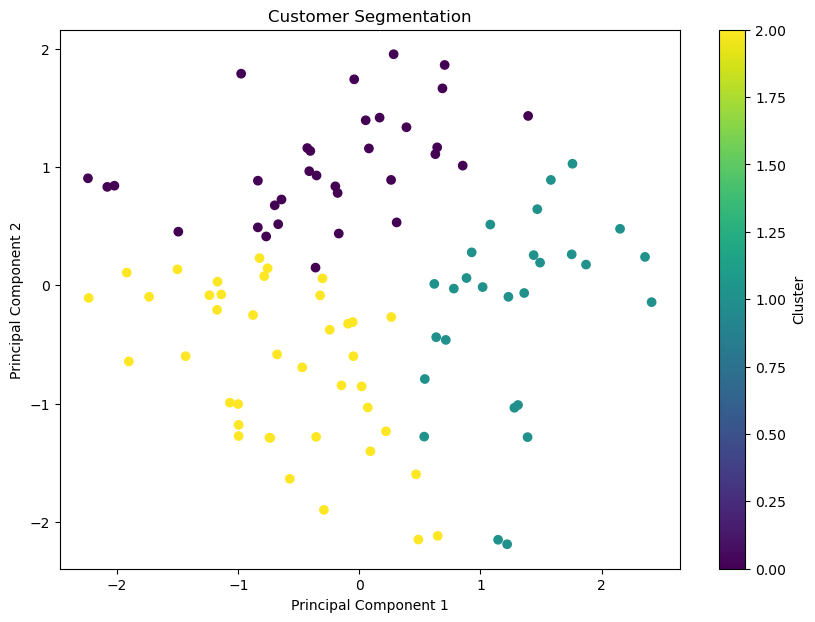

C:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


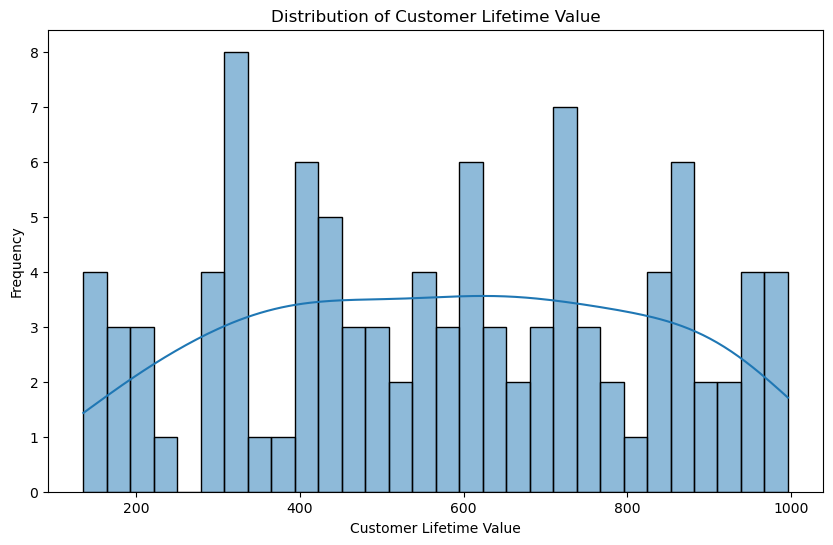

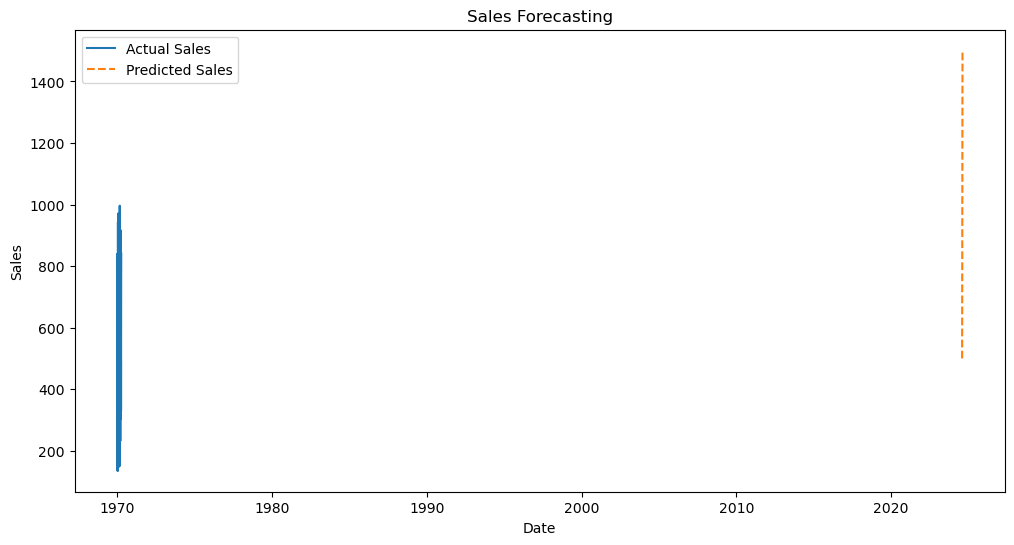

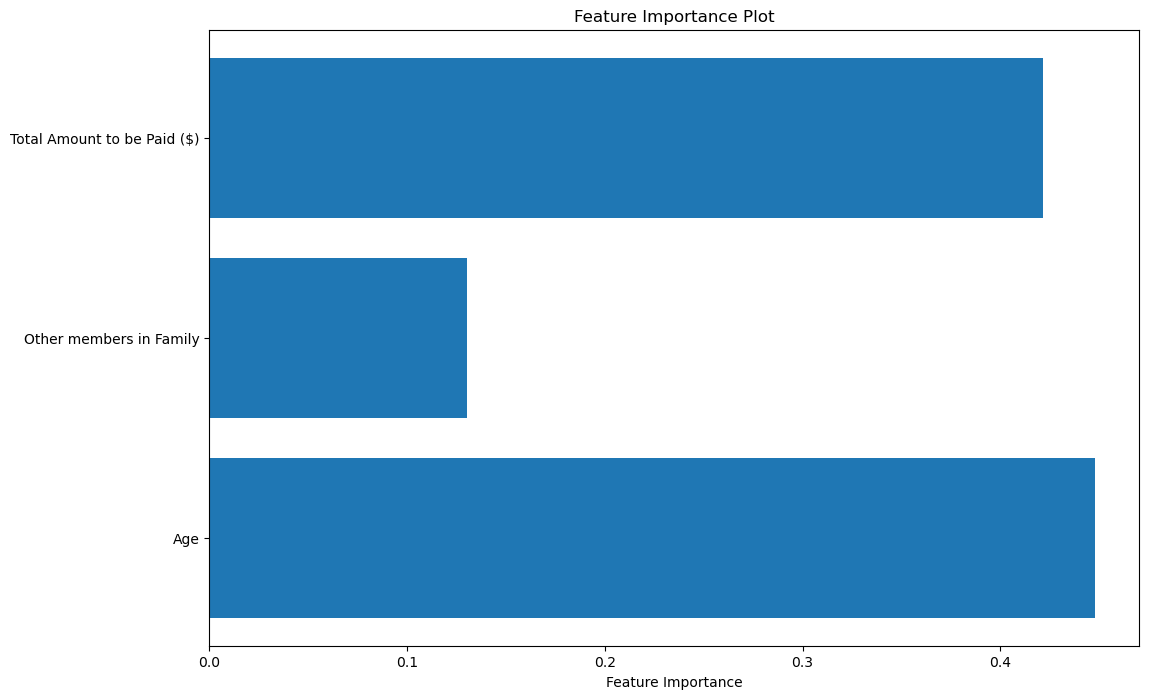

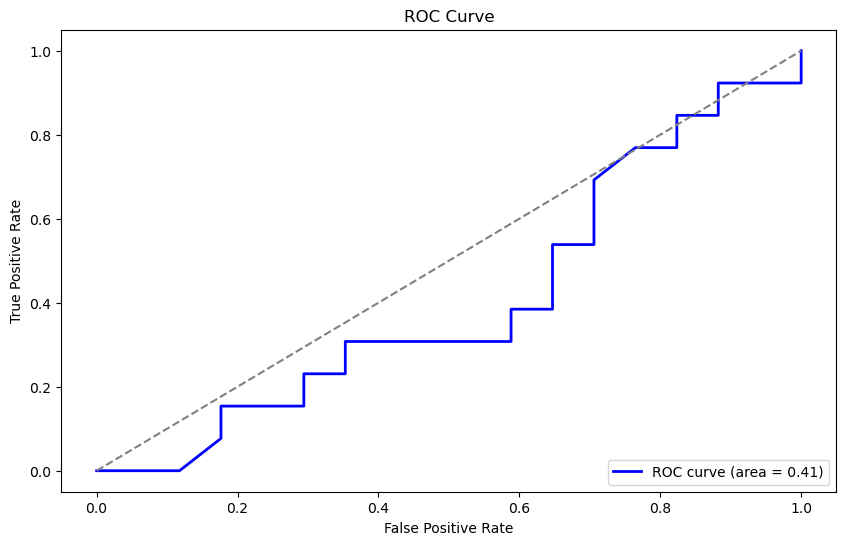

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load your data
df = pd.read_csv('instagram_users_data.csv')
# For demonstration, we'll create a sample dataset
np.random.seed(42)
data = {
    'title': np.random.choice(['Mr', 'Ms', 'Mrs'], 100),
    'first_name': np.random.choice(['John', 'Jane', 'Doe'], 100),
    'last_name': np.random.choice(['Smith', 'Doe', 'Brown'], 100),
    'Age': np.random.uniform(18, 70, 100),
    'Other members in Family': np.random.randint(1, 5, 100),
    'Total Amount to be Paid ($)': np.random.uniform(100, 1000, 100),
    'Churn': np.random.choice([0, 1], 100)  # 0 = No Churn, 1 = Churn
}
df = pd.DataFrame(data)

# Preprocessing
df_encoded = pd.get_dummies(df.drop(columns=['title', 'first_name', 'last_name']), drop_first=True)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train models
# Classification model (for churn prediction)
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Clustering model (for customer segmentation)
cluster_model = KMeans(n_clusters=3)
cluster_model.fit(X_scaled)

# Predictions
y_prob = clf.predict_proba(X_test)[:, 1]
cluster_predictions = cluster_model.predict(X_scaled)

# Visualizations

# 1. Customer Segmentation Visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
df_pca['Cluster'] = cluster_predictions

plt.figure(figsize=(10, 7))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segmentation')
plt.colorbar(label='Cluster')
plt.show()

# 2. Customer Lifetime Value (CLV) Prediction
# Assuming Total Amount to be Paid ($) is the CLV for demonstration
plt.figure(figsize=(10, 6))
sns.histplot(df['Total Amount to be Paid ($)'], bins=30, kde=True)
plt.xlabel('Customer Lifetime Value')
plt.ylabel('Frequency')
plt.title('Distribution of Customer Lifetime Value')
plt.show()

# 3. Sales Forecasting
# For simplicity, we'll use a dummy example as actual sales forecasting requires time-series data
# Assuming a basic linear trend
future_dates = pd.date_range(start='2024-08-01', periods=10, freq='D')
future_sales = np.linspace(500, 1500, 10)

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Total Amount to be Paid ($)'], label='Actual Sales')
plt.plot(future_dates, future_sales, label='Predicted Sales', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Sales Forecasting')
plt.legend()
plt.show()

# 4. Feature Importance Visualization
importances = clf.feature_importances_
feature_names = X.columns

plt.figure(figsize=(12, 8))
plt.barh(feature_names, importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance Plot')
plt.show()

# 5. Churn Prediction
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()
